In [41]:
# Makes sure that the notebook is reloaded when changes are made to other files in the project
%load_ext autoreload
%autoreload 2

import sys

# check if i am running in the same python environment as vscode
terminal_venv = '/Users/giorgosvlachonikoleas/Developer/Spheroid_PINN_Project/venv/bin/python'
if sys.executable == terminal_venv:
    print(f"Running in the same python environment as vscode\n{sys.executable}")
else:
    print(f"Running in a different python environment than vscode\n{sys.executable}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Running in the same python environment as vscode
/Users/giorgosvlachonikoleas/Developer/Spheroid_PINN_Project/venv/bin/python


 --- Starting experiment on device mps
neural network weights initialized succesfully
 ==================== Solver Manager ====================
 
data generator seed: 42
approximator seed: 42
device: mps
dtype: torch.float32
 -------------------- Dataset information -------------------- 
PDE dataset: 2000 points, sampling type: lhc, device: mps, dtype: torch.float32
Boundary dataset (left): 200 points, device: mps, dtype: torch.float32
Boundary dataset (right): 200 points, device: mps, dtype: torch.float32
Initial condition dataset: 100 points, device: mps, dtype: torch.float32
 -------------------- Neural network information -------------------- 
Neural network with 6 layers and 20 neurons in each layer
Output size: 3 x (batch_size * 1)
PINN(
  (activation): Tanh()
  (layers): ModuleList(
    (0): Linear(in_features=2, out_features=20, bias=True)
    (1-4): 4 x Linear(in_features=20, out_features=20, bias=True)
    (5): Linear(in_features=20, out_features=3, bias=True)
  )
)


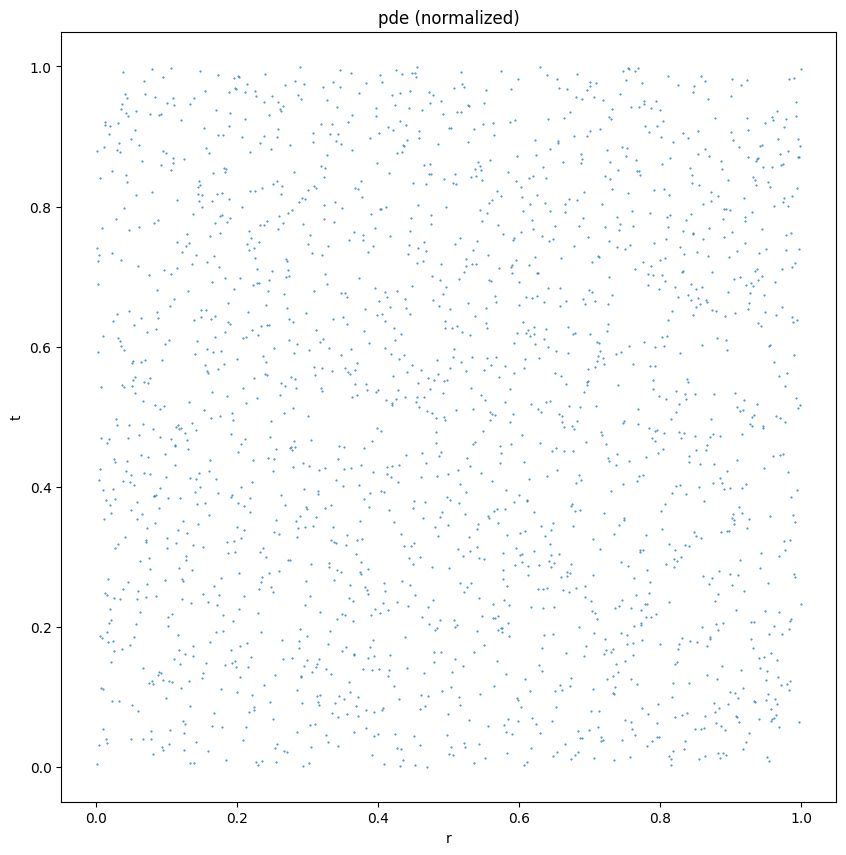

 --- Starting Adam optimization --- 
epochs: 10000
problem type: forward
vanilla method applied

inspect vanilla optimizer
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    name: network
    weight_decay: 0
)
------------------------------------------------------------------------------------------------------
  Epoch    |   Total    |    pde1    |    pde2    |    pde3    |    bc0     |    bcR     |     ic     
------------------------------------------------------------------------------------------------------
    0      | 8.6946e+08 | 8.6946e+08 | 2.7524e-03 | 6.6337e-12 | 2.8565e-04 | 7.4202e-06 | 4.1279e-02 
   200     | 9.7873e+06 | 9.7873e+06 | 2.6808e-04 | 6.8592e-12 | 3.8259e-04 | 3.6833e-07 | 3.7616e-02 
   400     | 1.7247e+06 | 1.7247e+06 | 9.9303e-05 | 6.1654e-12 | 1.3627e-04 | 1.3447e-07

KeyboardInterrupt: 

In [42]:
import torch
import matplotlib.pyplot as plt

from physics.residuals import pde_loss_fn, bc_loss_fn, ic_loss_fn
from core.context import PhysicsContext, physics_configuration
from core.data import PINNDataset
from core.model import PINN
from core.solver import PINNSolver


# set the experiment seed
exp_seed = 42
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f' --- Starting experiment on device {device}')
# instantiate the solver
ctx = PhysicsContext(cfg=physics_configuration)
solver = PINNSolver(physics_context=ctx ,neurons=20, layers=6, n_pde=2000, pde_loss_fn=pde_loss_fn, bc_loss_fn=bc_loss_fn, ic_loss_fn=ic_loss_fn, device=device, seed=exp_seed)

# plot dataset
solver.pde_training_dataset.plotme()

# training pipeline
# train simple adam for some epochs
solver.train_adam(method='vanilla', epochs=10000)

# # fine tune with dynamic weight algorithm
# solver.train_adam(method='dynweight', epochs=15000, update_weights_every=20, wait_until=5000)

# # further fine-tune with adaptive resampling
# solver.train_adam(epochs=30000, problem_type='forward', method='adaptive_resampling', accumulate=False, rard_sample_size=500, resample_every=500, wait_until=5000)
# # plot residual maps
# # plot new dataset

# # train for some epochs with simple adam
# solver.train_adam(method='vanilla', epochs=5000)

# # final fine tuning with lbfgs algorithm - freeze dynamic weight here.
# solver.train_lbfgs(epochs=300, problem_type='forward')

# vizualization of the 2d concentrations
solver.vizualize_prediction('cf', [0, 6, 12, 18, 24])

# # vizualization of losses



In [ ]:
from core.context import PhysicsContext

cfg = {
    # physical scale constants
    'R': 200,
    'tau': 50,
    'C0': 60,
    # pde parameters
    'd': 8.38,
    'k_off': 4e-3,
    'k_d': 6.76,
    'k_int': 1.4e-5,
    'r_t': 1060.0,
    'p_up': 2.5e-4,
    'p_cl': 2.6e-1,
    # pde weights
    'eq1': 1.0,
    'eq2': 1.0,
    'eq3': 1.0,
    'center': 1.0,
    'surface': 1.0,
    'ic': 1.0
}  

ctx = PhysicsContext(cfg=cfg)
ctx.get_pde_parameters()
ctx.get_pde_parameters()

In [ ]:
from core.data import DataGenerator


pinn = PINN(n_layers=6, n_neurons=10, seed=42)
generator = DataGenerator()
pde_dataset = PINNDataset(2000, approximator=pinn, generator=generator, sampling_type='lhc')
pde_dataset.plotme()
ctx = PhysicsContext(cfg=cfg)
pde_loss_fn(approximator=pinn, data=pde_dataset, ctx=ctx)

In [ ]:
pinn.physics_context.pde_parameters

In [ ]:
from tabulate import tabulate
import pandas as pd

In [ ]:
data = [
    ['aaaa', 1223],
    ['bbbb', 'dfasf']
]
df = pd.DataFrame(data, columns=['metric', 'value'])
print(tabulate(df))

-  ----  -----
0  aaaa  1223
1  bbbb  dfasf
-  ----  -----


In [ ]:
header = f"{'Epoch':^10} | {'Total':^10} | {'pde1':^10} | {'pde2':^10} | {'pde3':^10} | {'bc0':^10} | {'bcR':^10} "
print('-' * len(header))
print(header)
print('-' * len(header))
line = f"{epoch:^10} | {loss.item:^10} | {'pde1':^10} | {'pde2':^10} | {'pde3':^10} | {'bc0':^10} | {'bcR':^10} "



-----------------------------------------------------------------------------------------
  Epoch    |   Total    |    pde1    |    pde2    |    pde3    |    bc0     |    bcR     
-----------------------------------------------------------------------------------------
